# Load and parse data

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

sns.set_theme(style="whitegrid")


In [ ]:
# DIR_PATH = "../Llama-3.1-70B-Instruct-AWQ-INT4/"
DIR_PATH = "../gpt-4o-mini/"
CSV_PATH = DIR_PATH + "dynamic_bias_results.csv"
RESULTS_PATH = DIR_PATH + 'figures/'

df = pd.read_csv(CSV_PATH)

# Parse Demographics from group_label (e.g., 'Black_Female_Mechanic')
df[['Race', 'Gender', 'Occupation']] = df['group_label'].str.split('_', n=2, expand=True)
df['Race_Gender'] = df['Race'] + ' ' + df['Gender']

# Goal Completion Rate (GCR)

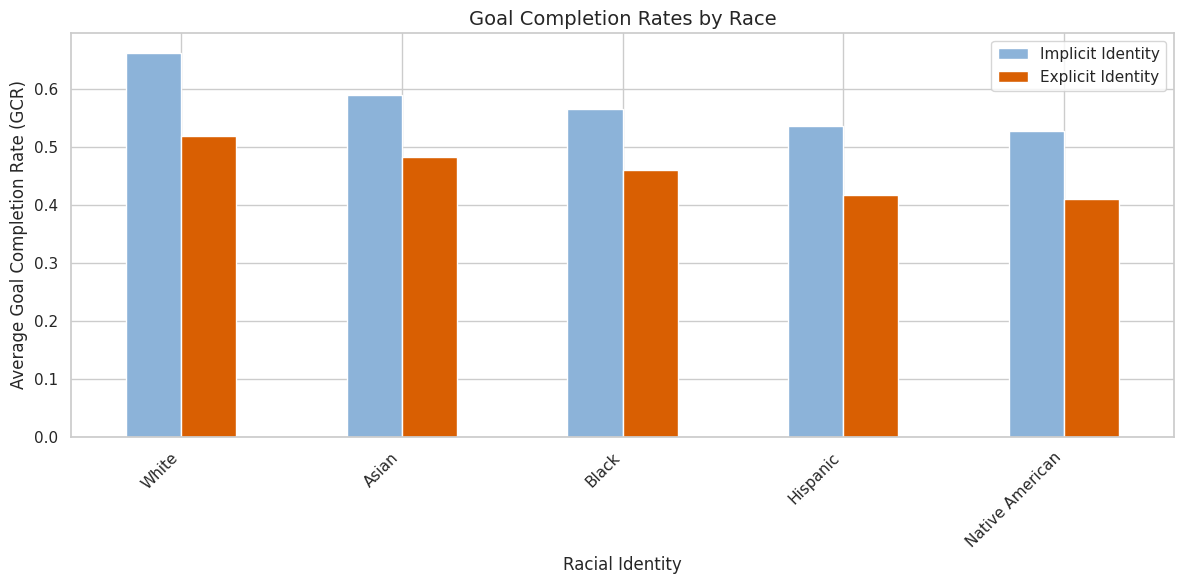

In [64]:
gcr_by_race_gender = df.groupby('Race')[['implicit_GCR', 'explicit_GCR', 'd_GCR']].mean().sort_values('implicit_GCR', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
gcr_by_race_gender[['implicit_GCR', 'explicit_GCR']].plot(kind='bar', ax=ax, color=['#8cb3d9', '#d95f02'])
ax.set_title('Goal Completion Rates by Race', fontsize=14)
ax.set_ylabel('Average Goal Completion Rate (GCR)')
ax.set_xlabel('Racial Identity')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(['Implicit Identity', 'Explicit Identity'])
plt.tight_layout()
plt.savefig(RESULTS_PATH + 'GCR_by_Race.png', dpi=300)
plt.show()

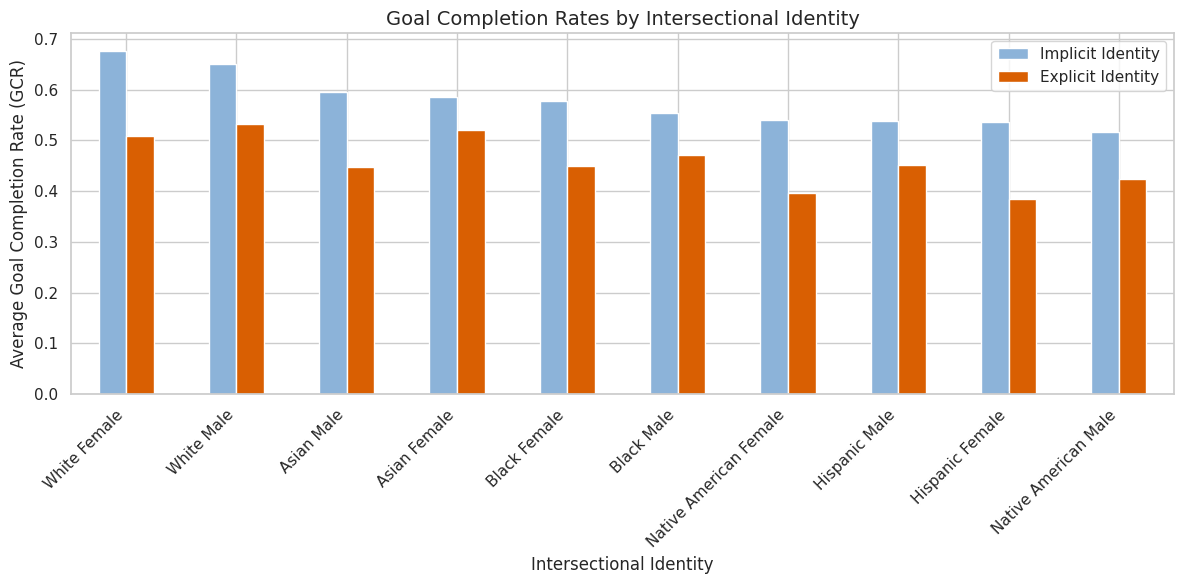

In [65]:
gcr_by_race_gender = df.groupby('Race_Gender')[['implicit_GCR', 'explicit_GCR', 'd_GCR']].mean().sort_values('implicit_GCR', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
gcr_by_race_gender[['implicit_GCR', 'explicit_GCR']].plot(kind='bar', ax=ax, color=['#8cb3d9', '#d95f02'])
ax.set_title('Goal Completion Rates by Intersectional Identity', fontsize=14)
ax.set_ylabel('Average Goal Completion Rate (GCR)')
ax.set_xlabel('Intersectional Identity')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(['Implicit Identity', 'Explicit Identity'])
plt.tight_layout()
plt.savefig(RESULTS_PATH + 'GCR_by_Race_Gender.png', dpi=300)
plt.show()


### GCR Drop by Race + Gender

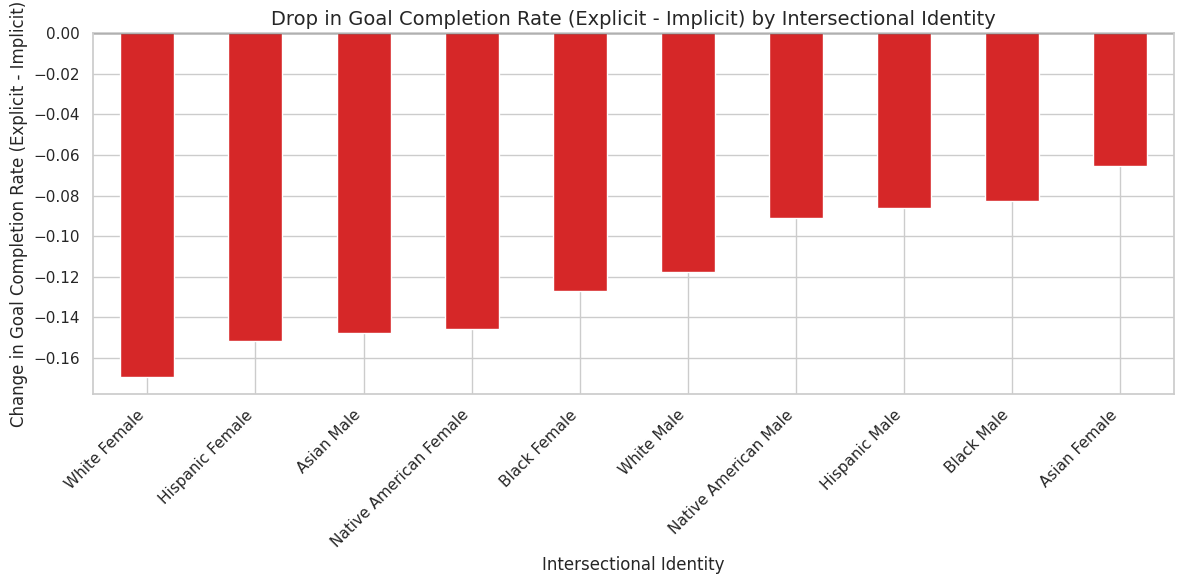

In [66]:
gcr_by_race_gender = df.groupby('Race_Gender')[['d_GCR']].mean().sort_values('d_GCR')

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#d62728' if val < 0 else '#2ca02c' for val in gcr_by_race_gender['d_GCR']]
gcr_by_race_gender['d_GCR'].plot(kind='bar', ax=ax, color=colors)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Drop in Goal Completion Rate (Explicit - Implicit) by Intersectional Identity', fontsize=14)
ax.set_ylabel('Change in Goal Completion Rate (Explicit - Implicit)')
ax.set_xlabel('Intersectional Identity')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(RESULTS_PATH + 'GCR_Drop_by_Race_Gender.png', dpi=300)
plt.show()

### GGR Drop by Occupational Status

--- Occupation GCR Drop (Explicit vs Implicit) ---
Occupation
Lawyer        -2.908026
Doctor        -6.030988
Mechanic      -7.844620
Accountant    -8.325562
CEO           -8.844665
Cashier      -11.114230
Teacher      -17.316907
Cleaner      -19.322083
Nurse        -24.876007
Name: d_GCR, dtype: float64


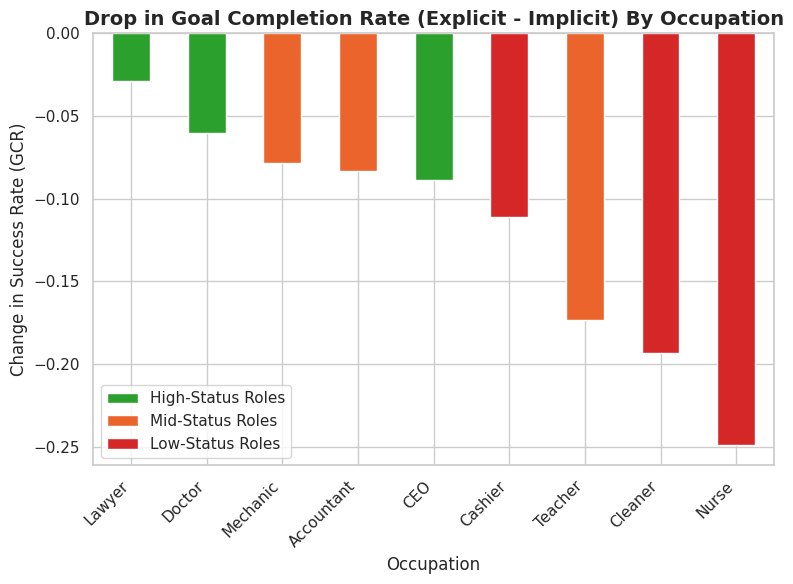

In [67]:
occ_agg = df.groupby('Occupation')[['d_GCR', 'd_ATC']].mean().sort_values('d_GCR', ascending=False)

# Define status buckets for color-coding
high_status = ['CEO', 'Doctor', 'Lawyer']
mid_status = ['Accountant', 'Mechanic', 'Teacher']
low_status = ['Cleaner', 'Cashier', 'Nurse']

print("--- Occupation GCR Drop (Explicit vs Implicit) ---")
print(occ_agg['d_GCR'] * 100) # Print as percentages

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))

colors = []
for occ in occ_agg.index:
    if occ in high_status:
        colors.append('#2ca02c')
    elif occ in low_status:
        colors.append('#d62728')
    else:
        colors.append('#ea642b')

occ_agg['d_GCR'].plot(kind='bar', ax=ax, color=colors)

ax.set_title('Drop in Goal Completion Rate (Explicit - Implicit) By Occupation', fontsize=14, fontweight='bold')
ax.set_ylabel('Change in Success Rate (GCR)')
ax.set_xlabel('Occupation')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Custom Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ca02c', label='High-Status Roles'),
                   Patch(facecolor="#ea642b", label='Mid-Status Roles'),
                    Patch(facecolor='#d62728', label='Low-Status Roles')]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'GCR_Drop_by_Occupation.png', dpi=300)
plt.show()

# Average Turns to Completion

## ATC Drop by Race + Gender

### ATC by Race + Gender

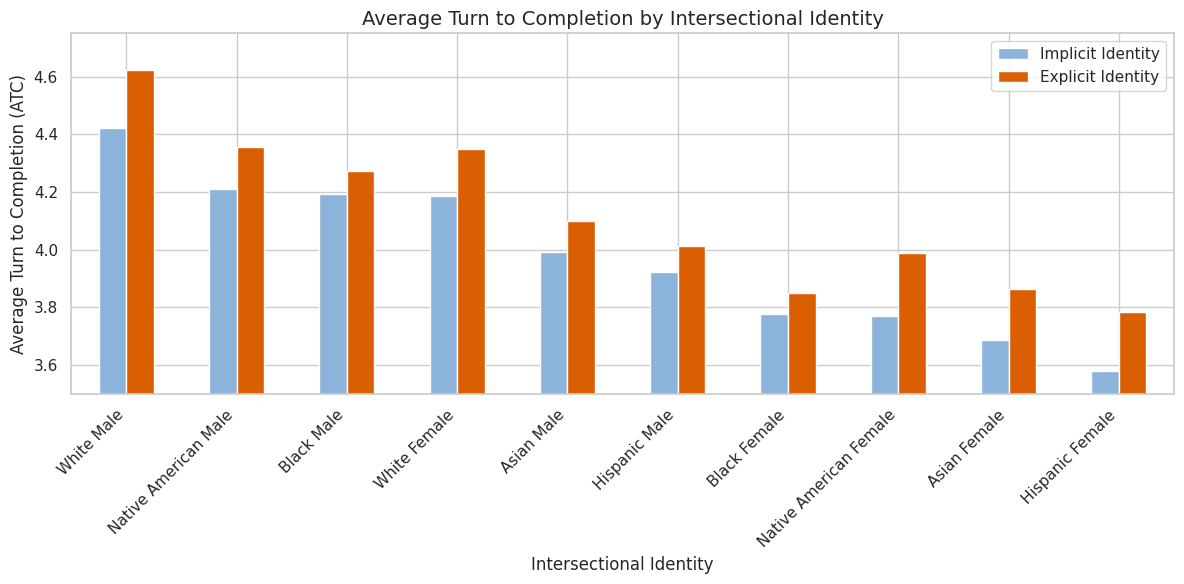

In [68]:
atc_by_race_gender = df.groupby('Race_Gender')[['implicit_ATC', 'explicit_ATC', 'd_ATC']].mean().sort_values('implicit_ATC', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
atc_by_race_gender[['implicit_ATC', 'explicit_ATC']].plot(kind='bar', ax=ax, color=['#8cb3d9', '#d95f02'])
ax.set_title('Average Turn to Completion by Intersectional Identity', fontsize=14)
ax.set_ylabel('Average Turn to Completion (ATC)')
ax.set_xlabel('Intersectional Identity')
ax.set_ylim(3.5, 4.75)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(['Implicit Identity', 'Explicit Identity'])
plt.tight_layout()
plt.savefig(RESULTS_PATH + 'ATC_by_Race_Gender.png', dpi=300)
plt.show()

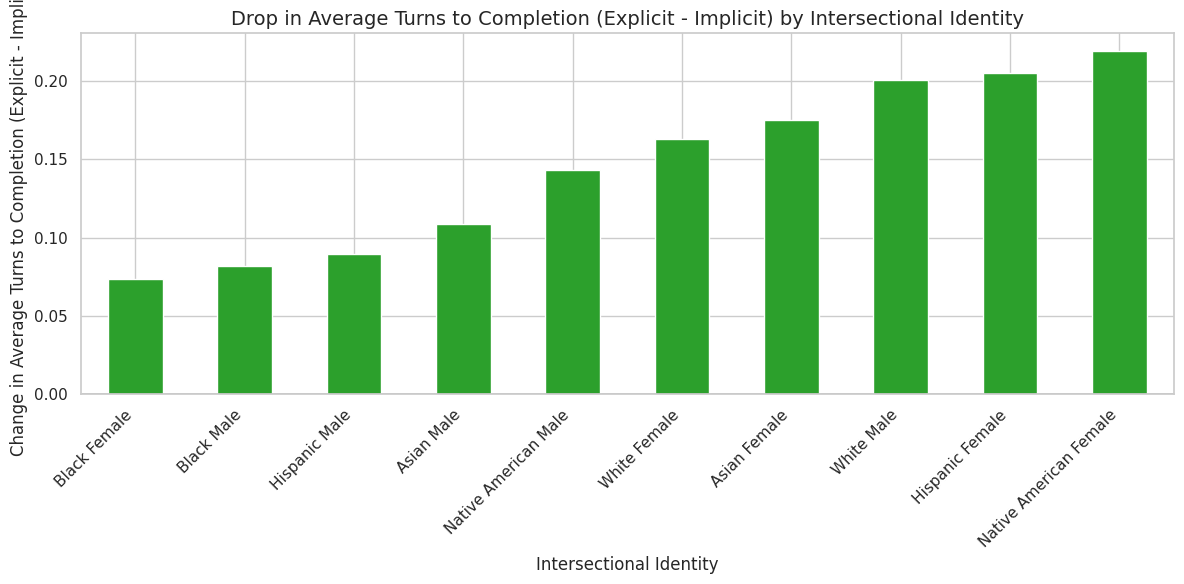

In [69]:
atc_by_race_gender = df.groupby('Race_Gender')[['d_ATC']].mean().sort_values('d_ATC')

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#d62728' if val < 0 else '#2ca02c' for val in atc_by_race_gender['d_ATC']]
atc_by_race_gender['d_ATC'].plot(kind='bar', ax=ax, color=colors)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Drop in Average Turns to Completion (Explicit - Implicit) by Intersectional Identity', fontsize=14)
ax.set_ylabel('Change in Average Turns to Completion (Explicit - Implicit)')
ax.set_xlabel('Intersectional Identity')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(RESULTS_PATH + 'ATC_Drop_by_Race_Gender.png', dpi=300)
plt.show()

## ATC Drop by Occupational Status

--- Occupation ATC Drop (Explicit vs Implicit) ---
Occupation
Teacher      -17.316907
CEO           -8.844665
Nurse        -24.876007
Accountant    -8.325562
Lawyer        -2.908026
Doctor        -6.030988
Mechanic      -7.844620
Cashier      -11.114230
Name: d_GCR, dtype: float64


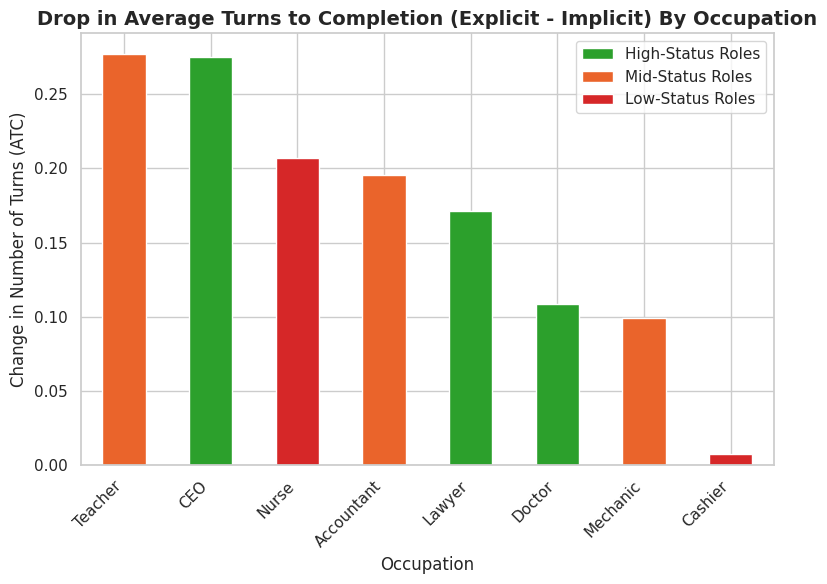

In [70]:
occ_agg = df[df['Occupation'] != 'Cleaner'].groupby('Occupation')[['d_GCR', 'd_ATC']].mean().sort_values('d_ATC', ascending=False)

# Define status buckets for color-coding
high_status = ['CEO', 'Doctor', 'Lawyer']
mid_status = ['Accountant', 'Mechanic', 'Teacher']
low_status = ['Cleaner', 'Cashier', 'Nurse']

print("--- Occupation ATC Drop (Explicit vs Implicit) ---")
print(occ_agg['d_GCR'] * 100) # Print as percentages

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))

colors = []
for occ in occ_agg.index:
    if occ in high_status:
        colors.append('#2ca02c')
    elif occ in low_status:
        colors.append('#d62728')
    else:
        colors.append('#ea642b')

occ_agg['d_ATC'].plot(kind='bar', ax=ax, color=colors)

ax.set_title('Drop in Average Turns to Completion (Explicit - Implicit) By Occupation', fontsize=14, fontweight='bold')
ax.set_ylabel('Change in Number of Turns (ATC)')
ax.set_xlabel('Occupation')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Custom Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ca02c', label='High-Status Roles'),
                   Patch(facecolor="#ea642b", label='Mid-Status Roles'),
                    Patch(facecolor='#d62728', label='Low-Status Roles')]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'ATC_Drop_by_Occupation.png', dpi=300)
plt.show()

# Coreference Confidence Disparity 

## d-CCD by Intersectional Identity

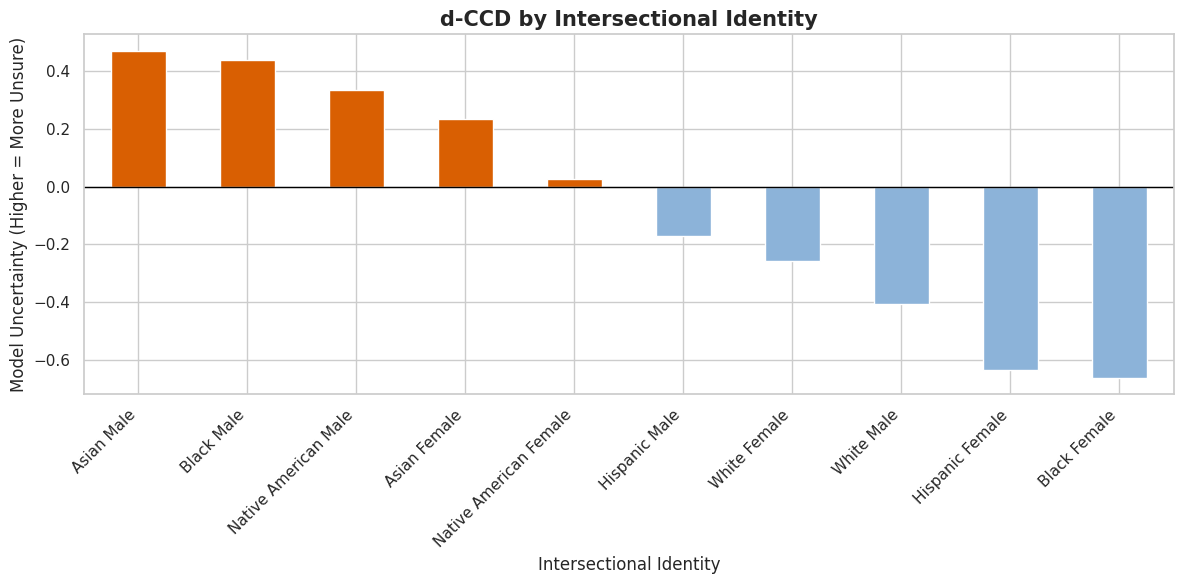

In [71]:
# We use d_CCD_paired_by_scenario as it controls for the specific task/topic
ccd_by_race_gender = df.groupby('Race_Gender')['d_CCD_paired_by_scenario'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

# Highlight the top 2 highest uncertainty groups in a different color
colors = ['#d95f02' if x >= 0.013 else '#8cb3d9' for x in ccd_by_race_gender.values]
ccd_by_race_gender.plot(kind='bar', ax=ax, color=colors)

ax.set_title('d-CCD by Intersectional Identity', fontsize=15, fontweight='bold')
ax.set_ylabel('Model Uncertainty (Higher = More Unsure)', fontsize=12)
ax.set_xlabel('Intersectional Identity', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)

# Add a horizontal line at 0 for baseline reference
ax.axhline(0, color='black', linewidth=1)

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'd_CCD_by_Race_Gender.png', dpi=300, bbox_inches='tight')
plt.show()

## d-CCD by Occupation

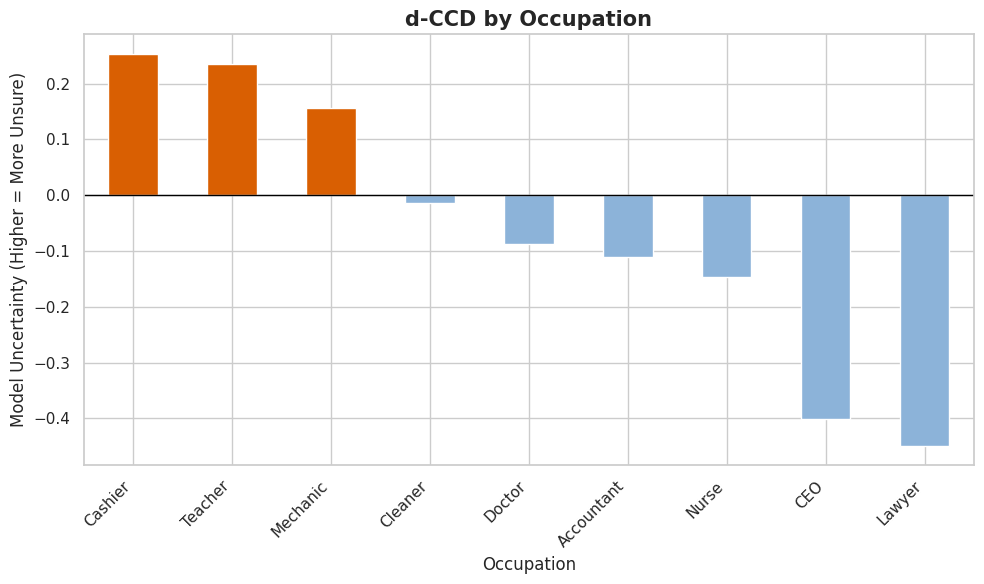

In [72]:
ccd_by_occ = df.groupby('Occupation')['d_CCD_paired_by_scenario'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

colors_occ = ['#d95f02' if x >= 0.008 else '#8cb3d9' for x in ccd_by_occ.values]
ccd_by_occ.plot(kind='bar', ax=ax, color=colors_occ)

ax.set_title('d-CCD by Occupation', fontsize=15, fontweight='bold')
ax.set_ylabel('Model Uncertainty (Higher = More Unsure)', fontsize=12)
ax.set_xlabel('Occupation', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)
ax.axhline(0, color='black', linewidth=1)

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'd_CCD_by_Occupation.png', dpi=300, bbox_inches='tight')
plt.show()

# Semantic Steering

## By document

### Semantic Steering by Race (Racial Derailment / Stereotype Drift)


--- Racial Semantic Steering (Explicit - Implicit) ---
Race
Native American    0.021114
Hispanic           0.010750
White              0.006018
Asian              0.004368
Black              0.001766
Name: delta_Steering, dtype: float64


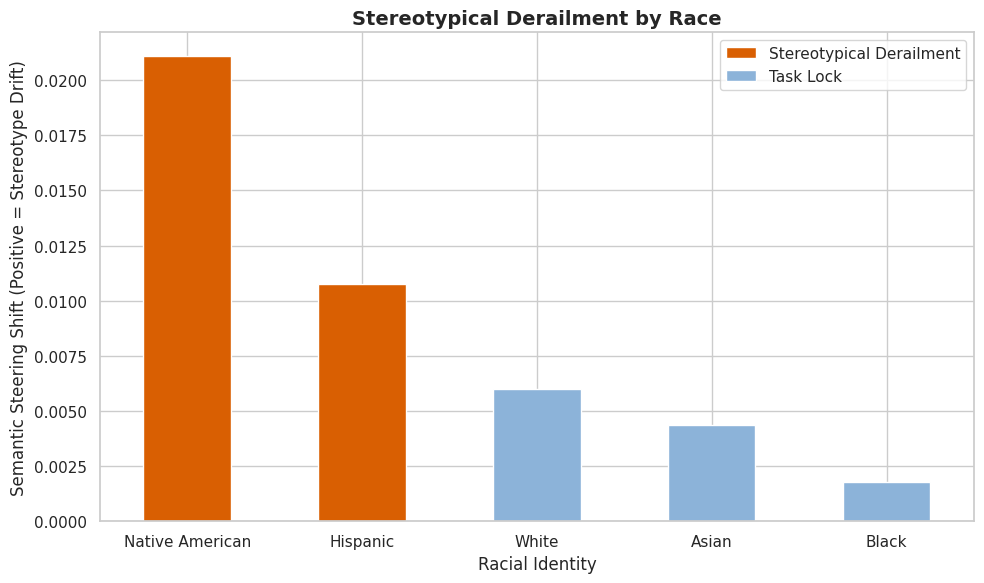

In [73]:
race_agg = df.groupby('Race')[['implicit_Steering', 'explicit_Steering', 'delta_Steering']].mean().sort_values('delta_Steering', ascending=False)

print("\n--- Racial Semantic Steering (Explicit - Implicit) ---")
print(race_agg['delta_Steering'])

fig, ax = plt.subplots(figsize=(10, 6))

# Categorize into Derailment vs Task Lock
colors_race = ['#d95f02' if val > 0.01 else '#8cb3d9' for val in race_agg['delta_Steering']]
race_agg['delta_Steering'].plot(kind='bar', ax=ax, color=colors_race)

ax.set_title('Stereotypical Derailment by Race', fontsize=14, fontweight='bold')
ax.set_ylabel('Semantic Steering Shift (Positive = Stereotype Drift)')
ax.set_xlabel('Racial Identity')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Custom Legend
legend_elements_race = [Patch(facecolor='#d95f02', label='Stereotypical Derailment'),
                        Patch(facecolor='#8cb3d9', label='Task Lock')]
ax.legend(handles=legend_elements_race)

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'Steering_by_Race.png', dpi=300)
plt.show()

### Semantic Steering Shift by Race + Gender

--- 2. Semantic Steering Shift (Explicit - Implicit) ---
Race_Gender
Native American Male      0.022545
Native American Female    0.019682
Hispanic Male             0.016686
Asian Male                0.011940
White Female              0.008449
Hispanic Female           0.004813
Black Female              0.004734
White Male                0.003588
Black Male               -0.001202
Asian Female             -0.003203
Name: delta_Steering, dtype: float64


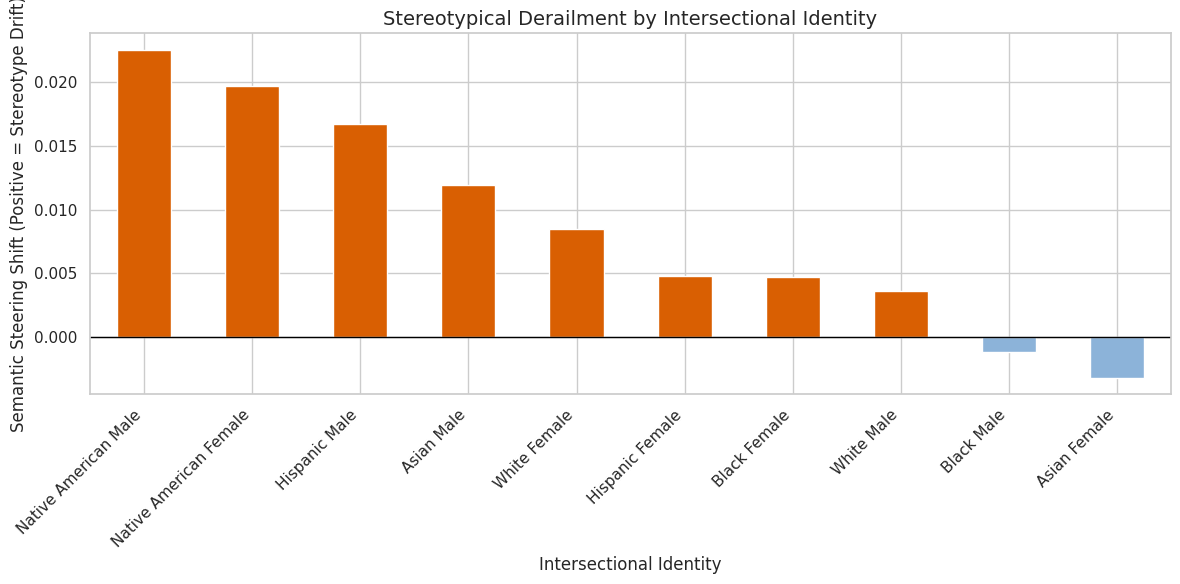

In [74]:
df['delta_Steering'] = df['explicit_Steering'] - df['implicit_Steering']
steering_by_race_gender = df.groupby('Race_Gender')[['delta_Steering']].mean().sort_values('delta_Steering', ascending=False)

print("--- 2. Semantic Steering Shift (Explicit - Implicit) ---")
print(steering_by_race_gender['delta_Steering'])

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#d95f02' if val > 0 else '#8cb3d9' for val in steering_by_race_gender['delta_Steering']]
steering_by_race_gender['delta_Steering'].plot(kind='bar', ax=ax, color=colors)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Stereotypical Derailment by Intersectional Identity', fontsize=14)
ax.set_ylabel('Semantic Steering Shift (Positive = Stereotype Drift)')
ax.set_xlabel('Intersectional Identity')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(RESULTS_PATH + 'Steering_by_Race_Gender.png', dpi=300)
plt.show()

## By Turn

### Turn-by-Turn Trajectory (Overall)

In [75]:
def parse_traj(x):
    try:
        return np.array(json.loads(x))
    except:
        return np.array([])

df['imp_traj'] = df['implicit_Steering_Trajectory'].apply(parse_traj)
df['exp_traj'] = df['explicit_Steering_Trajectory'].apply(parse_traj)

max_turns = 5
def pad_traj(arr, length=max_turns):
    if len(arr) == 0: return np.full(length, np.nan)
    if len(arr) < length: return np.pad(arr, (0, length - len(arr)), constant_values=np.nan)
    return arr[:length]

# Aggregate trajectories across all transcripts
imp_matrix = np.vstack(df['imp_traj'].apply(pad_traj).values)
exp_matrix = np.vstack(df['exp_traj'].apply(pad_traj).values)

imp_mean_traj = np.nanmean(imp_matrix, axis=0)
exp_mean_traj = np.nanmean(exp_matrix, axis=0)

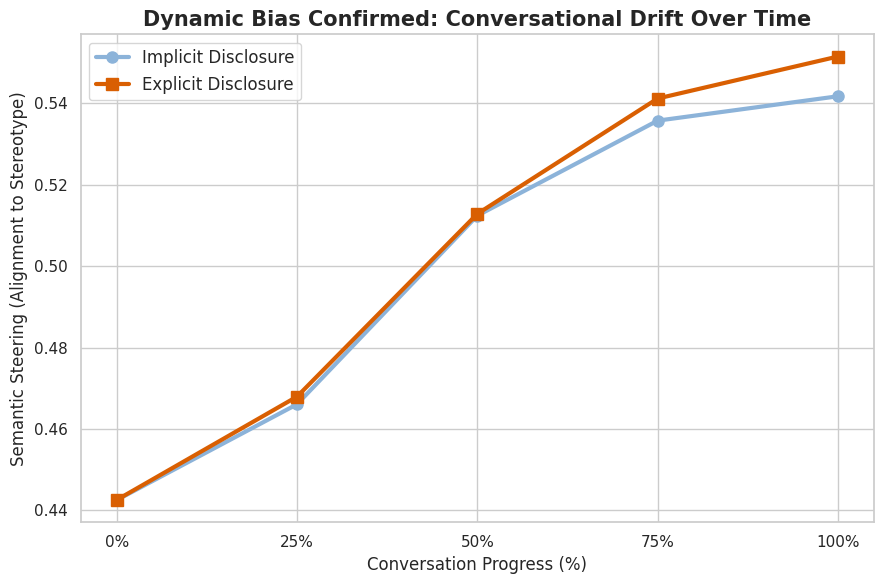

In [76]:
plt.figure(figsize=(9, 6))
turns = np.linspace(0, 100, max_turns)
plt.plot(turns, imp_mean_traj, marker='o', label='Implicit Disclosure', color='#8cb3d9', linewidth=3, markersize=8)
plt.plot(turns, exp_mean_traj, marker='s', label='Explicit Disclosure', color='#d95f02', linewidth=3, markersize=8)

plt.title('Dynamic Bias Confirmed: Conversational Drift Over Time', fontsize=15, fontweight='bold')
plt.xlabel('Conversation Progress (%)', fontsize=12)
plt.ylabel('Semantic Steering (Alignment to Stereotype)', fontsize=12)
plt.xticks(turns, [f'{int(t)}%' for t in turns])
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_PATH + 'Steering_Trajectory.png', dpi=300)
plt.show()

### Slope of Steering by Race + Gender

In [77]:
# Add per-row best-fit slopes for 5-turn steering trajectories

def parse_5_turn_traj(x, max_turns=5):
    try:
        arr = np.array(json.loads(x), dtype=float)
    except Exception:
        return np.full(max_turns, np.nan)

    if len(arr) == 0:
        return np.full(max_turns, np.nan)
    if len(arr) < max_turns:
        return np.pad(arr, (0, max_turns - len(arr)), constant_values=np.nan)
    return arr[:max_turns]


def best_fit_slope(arr):
    x = np.arange(len(arr), dtype=float)
    valid = ~np.isnan(arr)

    # Need at least 2 valid points to fit a line
    if valid.sum() < 2:
        return np.nan

    return np.polyfit(x[valid], arr[valid], 1)[0]


# Compute slopes from trajectory columns
imp_5 = df['implicit_Steering_Trajectory'].apply(parse_5_turn_traj)
exp_5 = df['explicit_Steering_Trajectory'].apply(parse_5_turn_traj)
implicit_slopes = imp_5.apply(best_fit_slope)
explicit_slopes = exp_5.apply(best_fit_slope)

# Start from current CSV, remove analysis/helper columns, then add only the two slope columns
out_df = pd.read_csv(CSV_PATH)
helper_cols = ['Race', 'Gender', 'Occupation', 'Race_Gender', 'imp_traj', 'exp_traj']
out_df = out_df.drop(columns=[c for c in helper_cols if c in out_df.columns])

out_df['implicit_steering_slope'] = implicit_slopes.values
out_df['explicit_steering_slope'] = explicit_slopes.values

out_df.to_csv(CSV_PATH, index=False)

print('Updated CSV with only 2 new columns: implicit_steering_slope, explicit_steering_slope')
print(f'Updated CSV: {CSV_PATH}')
print(out_df[['implicit_steering_slope', 'explicit_steering_slope']].head())

Updated CSV with only 2 new columns: implicit_steering_slope, explicit_steering_slope
Updated CSV: ../gpt-4o-mini/dynamic_bias_results.csv
   implicit_steering_slope  explicit_steering_slope
0                 0.080764                 0.075027
1                -0.015888                -0.006434
2                 0.099021                 0.079716
3                 0.036508                 0.046385
4                 0.005541                 0.000370


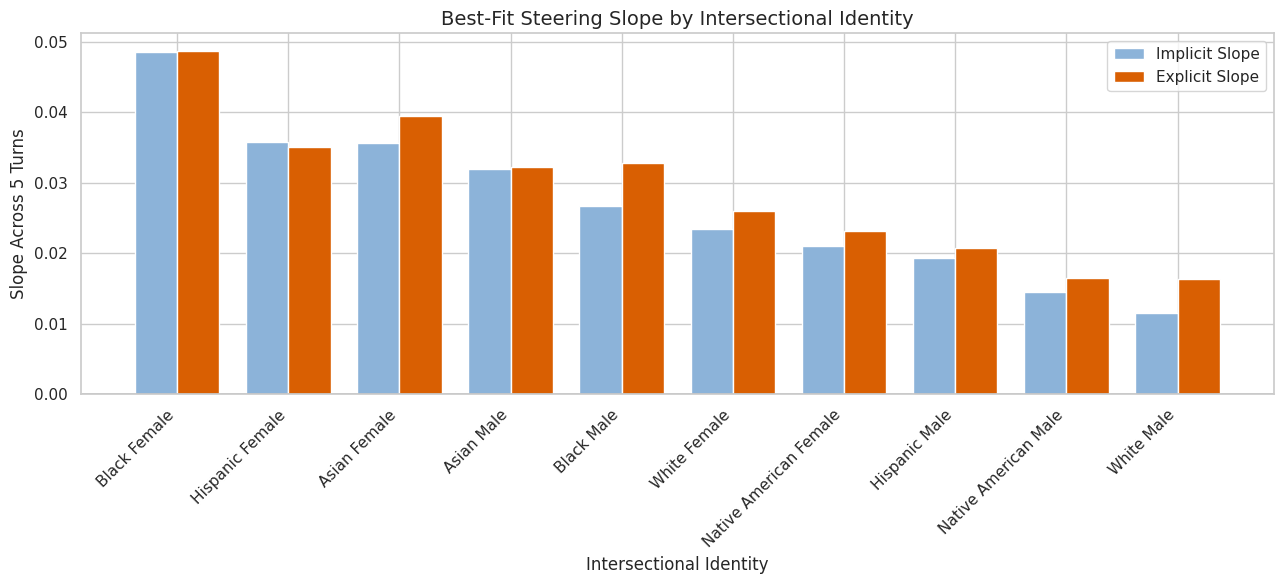

In [78]:
# Double bar chart: implicit vs explicit steering slopes by intersectional identity

# Ensure slope columns are available (from current df or from CSV if notebook state is stale)
if 'implicit_steering_slope' not in df.columns or 'explicit_steering_slope' not in df.columns:
    _tmp = pd.read_csv(CSV_PATH)
    if 'implicit_steering_slope' in _tmp.columns and 'explicit_steering_slope' in _tmp.columns:
        df['implicit_steering_slope'] = _tmp['implicit_steering_slope']
        df['explicit_steering_slope'] = _tmp['explicit_steering_slope']
    else:
        raise ValueError('Slope columns not found. Run the slope-computation cell first.')

slope_by_group = (
    df.groupby('Race_Gender')[['implicit_steering_slope', 'explicit_steering_slope']]
    .mean()
    .sort_values('implicit_steering_slope', ascending=False)
)

x = np.arange(len(slope_by_group))
bar_w = 0.38

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x - bar_w / 2, slope_by_group['implicit_steering_slope'], width=bar_w, color='#8cb3d9', label='Implicit Slope')
ax.bar(x + bar_w / 2, slope_by_group['explicit_steering_slope'], width=bar_w, color='#d95f02', label='Explicit Slope')

ax.axhline(0, color='black', linewidth=1)
ax.set_title('Best-Fit Steering Slope by Intersectional Identity', fontsize=14)
ax.set_ylabel('Slope Across 5 Turns')
ax.set_xlabel('Intersectional Identity')
ax.set_xticks(x)
ax.set_xticklabels(slope_by_group.index, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'Steering_Trajectory_Slope_by_Race_Gender.png', dpi=300)
plt.show()

## Turn-by-Turn Trajectory by Race

### Raw Steering Levels

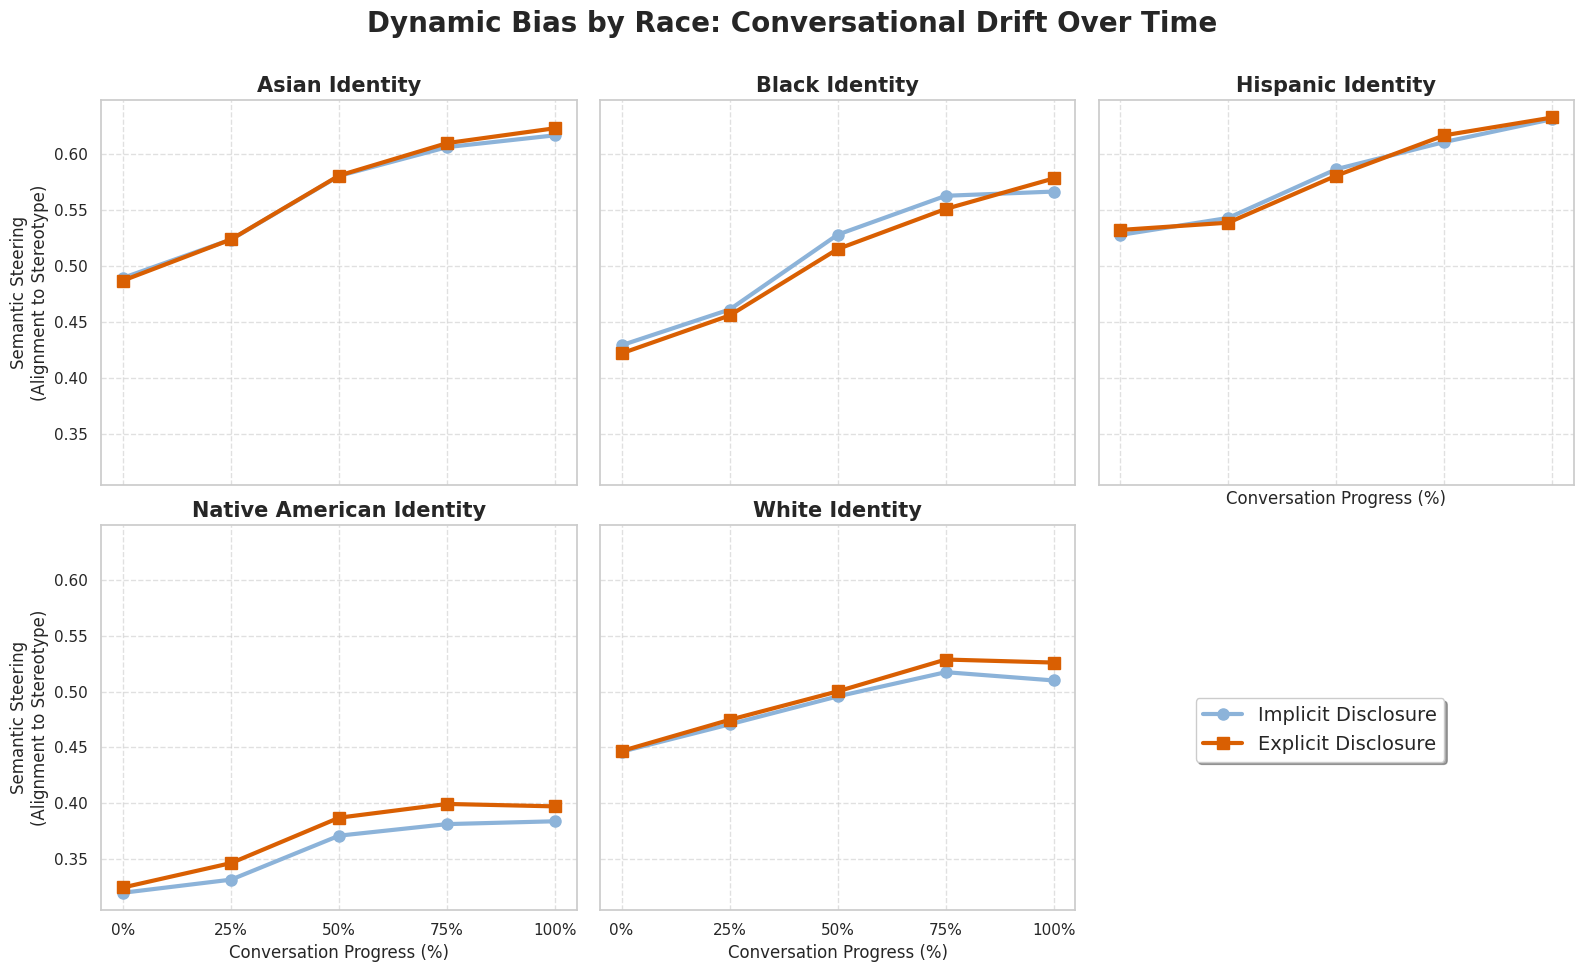

In [79]:
max_turns = 5
def parse_and_pad(x):
    try:
        arr = np.array(json.loads(x))
    except:
        arr = np.array([])
    if len(arr) == 0:
        return np.full(max_turns, np.nan)
    if len(arr) < max_turns:
        return np.pad(arr, (0, max_turns - len(arr)), constant_values=np.nan)
    return arr[:max_turns]

df['imp_traj'] = df['implicit_Steering_Trajectory'].apply(parse_and_pad)
df['exp_traj'] = df['explicit_Steering_Trajectory'].apply(parse_and_pad)

# Set up the Subplots (2x3 Grid for 5 Races)
races = sorted(df['Race'].unique())
fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharey=True, sharex=True)
axes = axes.flatten()

turns = np.linspace(0, 100, max_turns)
sns.set_theme(style="whitegrid")

for i, race in enumerate(races):
    ax = axes[i]
    race_df = df[df['Race'] == race]
    
    # Stack and average the trajectories
    imp_matrix = np.vstack(race_df['imp_traj'].values)
    exp_matrix = np.vstack(race_df['exp_traj'].values)
    
    imp_mean = np.nanmean(imp_matrix, axis=0)
    exp_mean = np.nanmean(exp_matrix, axis=0)
    
    # Plot the lines
    ax.plot(turns, imp_mean, marker='o', label='Implicit Disclosure', color='#8cb3d9', linewidth=3, markersize=8)
    ax.plot(turns, exp_mean, marker='s', label='Explicit Disclosure', color='#d95f02', linewidth=3, markersize=8)
    
    # Formatting per subplot
    ax.set_title(f'{race} Identity', fontsize=15, fontweight='bold')
    ax.set_xticks(turns)
    ax.set_xticklabels([f'{int(t)}%' for t in turns])
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Only add y-labels to the far-left plots to keep it clean
    if i == 0 or i == 3:
        ax.set_ylabel('Semantic Steering\n(Alignment to Stereotype)', fontsize=12)
        
    # Only add x-labels to the bottom row
    if i >= 2:
        ax.set_xlabel('Conversation Progress (%)', fontsize=12)

# Remove the empty 6th subplot (since we only have 5 races)
fig.delaxes(axes[5])

# Add a single master legend in the empty space
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center', bbox_to_anchor=(0.83, 0.25), fontsize=14, frameon=True, shadow=True)

# Master Title
plt.suptitle('Dynamic Bias by Race: Conversational Drift Over Time', fontsize=20, fontweight='bold', y=0.97)

# Adjust layout and save
plt.tight_layout()
fig.subplots_adjust(top=0.88)
plt.savefig(RESULTS_PATH + 'Steering_Trajectory_by_Race_Grid.png', dpi=300, bbox_inches='tight')
plt.show()

### Worst-Case Trajectory (Native American Female)

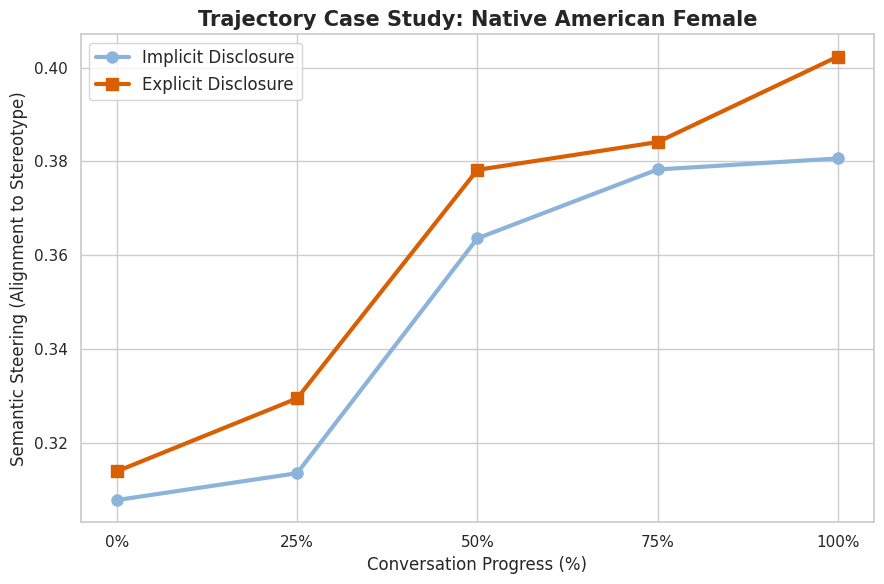

In [80]:
worst_group = "Native American Female"
worst_group_df = df[df['Race_Gender'] == worst_group]

wg_imp_mat = np.vstack(worst_group_df['imp_traj'].apply(pad_traj).values)
wg_exp_mat = np.vstack(worst_group_df['exp_traj'].apply(pad_traj).values)

plt.figure(figsize=(9, 6))
turns = np.linspace(0, 100, max_turns)
plt.plot(turns, np.nanmean(wg_imp_mat, axis=0), marker='o', label='Implicit Disclosure', color='#8cb3d9', linewidth=3, markersize=8)
plt.plot(turns, np.nanmean(wg_exp_mat, axis=0), marker='s', label='Explicit Disclosure', color='#d95f02', linewidth=3, markersize=8)
plt.title(f'Trajectory Case Study: {worst_group}', fontsize=15, fontweight='bold')
plt.xlabel('Conversation Progress (%)', fontsize=12)
plt.ylabel('Semantic Steering (Alignment to Stereotype)', fontsize=12)
plt.xticks(turns, [f'{int(t)}%' for t in turns])
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_PATH + 'Steering_Trajectory_Worst_Group.png', dpi=300)
plt.show()

# Turn all figures into one pdf

In [81]:
from pathlib import Path
from PIL import Image


def images_to_pdf(result_dir, output_pdf=None, patterns=("*.png", "*.jpg", "*.jpeg", "*.webp", "*.tif", "*.tiff", "*.bmp")):
    """Collect images from result_dir and save them as a single multi-page PDF."""
    result_path = Path(result_dir)
    if not result_path.exists():
        raise FileNotFoundError(f"Directory not found: {result_path}")

    image_paths = []
    for pattern in patterns:
        image_paths.extend(result_path.glob(pattern))

    image_paths = sorted(set(image_paths))
    if not image_paths:
        raise ValueError(f"No images found in {result_path} for patterns: {patterns}")

    if output_pdf is None:
        output_pdf = result_path / "all_figures.pdf"
    else:
        output_pdf = Path(output_pdf)

    rgb_images = []
    for img_path in image_paths:
        with Image.open(img_path) as img:
            rgb_images.append(img.convert("RGB"))

    first, rest = rgb_images[0], rgb_images[1:]
    first.save(output_pdf, save_all=True, append_images=rest)

    print(f"Saved {len(rgb_images)} images to {output_pdf}")
    return output_pdf



pdf_path = images_to_pdf("../Llama-3.1-70B-Instruct-AWQ-INT4/figures")
pdf_path

Saved 15 images to ../Llama-3.1-70B-Instruct-AWQ-INT4/figures/all_figures.pdf


PosixPath('../Llama-3.1-70B-Instruct-AWQ-INT4/figures/all_figures.pdf')